### Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn import svm
from sklearn.svm import LinearSVC
from pickle import dump
from scipy import sparse

import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input, Dropout

### Read train and test data

In [3]:
data = pd.read_csv('Processed_data.csv',index_col=0)
X_train = pd.read_csv('X_train.csv',index_col=0) 
X_test = pd.read_csv('X_test.csv',index_col=0)
y_train = pd.read_csv('y_train.csv',index_col=0)
y_test = pd.read_csv('y_test.csv',index_col=0)

In [4]:
stopwords_list = stopwords.words('english')

In [5]:
X_train.shape
X_test.shape


(8000, 1)

## Tf-Idf Embeddings

In [6]:
tfidf = TfidfVectorizer(stop_words = stopwords_list,ngram_range = (1,2))
tfidf_text_train = tfidf.fit_transform(X_train['headline'])
tfidf_text_test = tfidf.transform(X_test['headline'])

X_train_ef = X_train.drop(columns='headline')
X_test_ef = X_test.drop(columns='headline')

In [7]:
dump(tfidf,open('tfidf.pkl','wb'))

In [9]:
X_train = sparse.hstack([X_train_ef, tfidf_text_train]).tocsr()
X_test = sparse.hstack([X_test_ef, tfidf_text_test]).tocsr()

In [10]:
#creating a function to call after each model iteration to print accuracy and recall scores for test and train
def train_results(preds):
    return "Training Accuracy:", accuracy_score(y_train,preds)," Training Recall:", recall_score(y_train,preds), "F1 Score:",f1_score(y_train,preds) 

def test_results(preds):
    return "Testing Accuracy:", accuracy_score(y_test,preds)," Testing Recall:", recall_score(y_test,preds), "F1 Score:",f1_score(y_test,preds) 

# Random forest

In [11]:
#rf_classifier = RandomForestClassifier(class_weight = 'balanced', n_estimators = 900 )
rf_classifier = RandomForestClassifier(class_weight = 'balanced' )
rf_classifier.fit(X_train, y_train)

rf_test_preds = rf_classifier.predict(X_test)
print(test_results(rf_test_preds))

/tmp/ipykernel_52210/593194422.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rf_classifier.fit(X_train, y_train)


('Testing Accuracy:', 0.90225, ' Testing Recall:', 0.9730700179533214, 'F1 Score:', 0.9065710872162485)


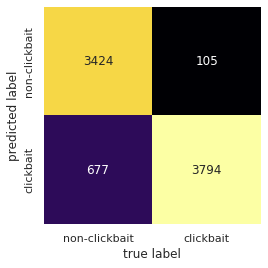

In [12]:
#confusion matrix on test set RFC Classifier
sns.set()

cm_dc = confusion_matrix(y_test, rf_test_preds)
sns.heatmap(cm_dc.T, square=True, annot=True, fmt='d', cbar=False,cmap="inferno", xticklabels=['non-clickbait','clickbait'],yticklabels=['non-clickbait','clickbait']
            )
plt.xlabel('true label')
plt.ylabel('predicted label');

# SVM

/home/pradyumna/.local/lib/python3.8/site-packages/sklearn/utils/validation.py:1111: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


('Testing Accuracy:', 0.95725, ' Testing Recall:', 0.9556296486278533, 'F1 Score:', 0.9561200923787527)


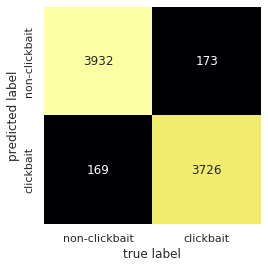

In [13]:
#SVM Model
svm_classifier = svm.SVC(kernel = 'linear', decision_function_shape='ovo')
#svm_classifier = LinearSVC(class_weight='balanced', C=10, max_iter = 1500 )

svm_classifier.fit(X_train, y_train)

svm_test_preds = svm_classifier.predict(X_test)


print(test_results(svm_test_preds))

#confusion matrix on test set SVM Classifier 
sns.set()

cm_dc = confusion_matrix(y_test, svm_test_preds)
sns.heatmap(cm_dc.T, square=True, annot=True, fmt='d', cbar=False,cmap="inferno", xticklabels=['non-clickbait','clickbait'],yticklabels=['non-clickbait','clickbait']
            )
plt.xlabel('true label')
plt.ylabel('predicted label');

## LSTM


In [14]:
X = data['headline']
y = data['clickbait']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20)


In [15]:
vocab_size = 7500
maxlen = 250
embedding_size = 64

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X)

X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

model = Sequential()
model.add(Embedding(vocab_size, embedding_size, input_length=maxlen))
model.add(LSTM(64))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

2023-03-22 21:09:08.138235: E tensorflow/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2023-03-22 21:09:08.144303: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (pradyumna): /proc/driver/nvidia/version does not exist
2023-03-22 21:09:08.217022: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 250, 64)           480000    
                                                                 
 lstm (LSTM)                 (None, 64)                33024     
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 517,249
Trainable params: 517,249
Non-trainable params: 0
_________________________________________________________________


In [19]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train, y_train, batch_size=512, validation_data=(X_test, y_test), epochs=3)

Epoch 1/3
19/50 [==========>...................] - ETA: 1:10 - loss: 0.0494 - accuracy: 0.9817

200/200 [==============================] - 10s 44ms/step
('Testing Accuracy:', 0.96, ' Testing Recall:', 0.9633198632266087, 'F1 Score:', 0.9603346761698172)


Text(89.18, 0.5, 'predicted label')

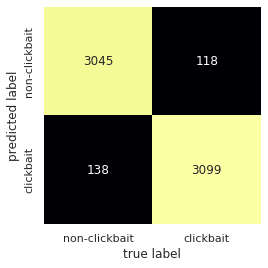

In [18]:
Lstm_test_preds = (model.predict(X_test) > 0.5)
print(test_results(Lstm_test_preds))

#confusion matrix on test set lstm Classifier 
sns.set()

cm_dc = confusion_matrix(y_test, Lstm_test_preds)
sns.heatmap(cm_dc.T, square=True, annot=True, fmt='d', cbar=False,cmap="inferno", xticklabels=['non-clickbait','clickbait'],yticklabels=['non-clickbait','clickbait']
            )
plt.xlabel('true label')
plt.ylabel('predicted label')